<div>
<img src="https://www.smu.edu.sg/themes/smubase_5g/assets/site-headers/logo-smu-d.svg?revised=20240229" width="200" height="200" align="center">
</div>

# Housing Prices

# Introduction
The goal of our project is to predict the sale prices of homes.

In [6]:
# Importing packages necessary for the analysis
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [7]:
# Save your file path for data here and copy into variable below:-
# Sid: /Users/siddharth/Downloads/
# Marius:
# Jelke:
# Fan: 

# update before you run:-
FILE_PATH = '/Users/siddharth/Downloads/'

# Importing the data 
train = pd.read_csv(FILE_PATH + 'train.csv')
test = pd.read_csv(FILE_PATH + 'test.csv')

# Data exploration 
## Summary of the data exploration.
In the data exploration we found the following:


In [8]:

#print(train.describe())
#print(train.info())
print(f"train: {train.shape}, test: {test.shape}")
train.head(10)
train.dtypes.value_counts()

train: (1460, 81), test: (1459, 80)


object     43
int64      35
float64     3
Name: count, dtype: int64

In [9]:
#number of missing values?
missing = train.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [10]:
# correlation with target
corr = train.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
corr.head(25)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
LotArea         0.263843
BsmtFullBath    0.227122
BsmtUnfSF       0.214479
BedroomAbvGr    0.168213
ScreenPorch     0.111447
Name: SalePrice, dtype: float64

Skew: 1.8828757597682129


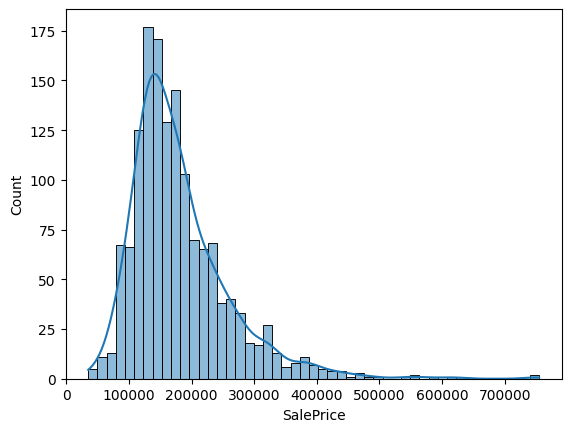

In [11]:
sns.histplot(train['SalePrice'], kde=True)
print(f'Skew: {train['SalePrice'].skew()}')

skew: 0.12133506220520406


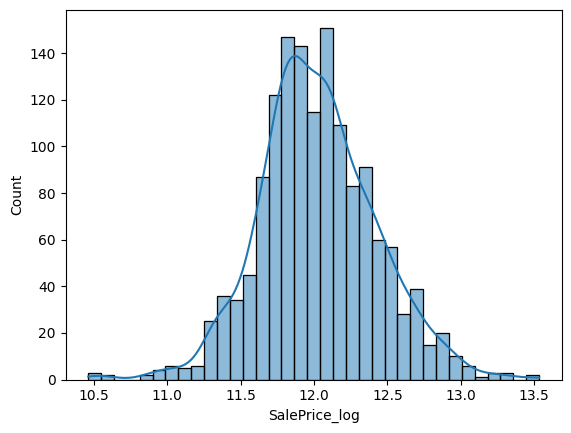

In [12]:
train['SalePrice_log'] = np.log(train['SalePrice'])
sns.histplot(train['SalePrice_log'], kde=True)
print(f'skew: {train['SalePrice_log'].skew()}')
#llog transformation of sale price: reduces the skew and moves us closer to normal

# Data Cleaning

In [13]:
y_train_raw = train["SalePrice"].reset_index(drop=True)
ntrain = train.shape[0]
all_data = pd.concat([train.drop(columns=["SalePrice"]), test], axis=0, ignore_index=True)

In [14]:
#columns where NA means none:
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
             "MasVnrType"]
for c in none_cols:
    all_data[c] = all_data[c].fillna("None")

#columns wheere NA means 0
zero_cols = ["GarageYrBlt", "GarageArea", "GarageCars",
             "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
             "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"]
for c in zero_cols:
    all_data[c] = all_data[c].fillna(0)

# Utilities: almost constant --> drop column
#all_data = all_data.drop(columns=["Utilities"])

# Numerical columns that should be traeated as categorical
all_data["MSSubClass"] = all_data["MSSubClass"].astype(str)
all_data["MoSold"] = all_data["MoSold"].astype(str)

#LotFrontage --> impute by median based on neighborhood?
all_data["LotFrontage"] = all_data["LotFrontage"].fillna(
    all_data.groupby("Neighborhood")["LotFrontage"].transform("median")
)

#MSZoning --> zoning classification of the sale --> use neighboorhood mode?
all_data['MSZoning'] = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0])

In [15]:
remaining_na = all_data.isnull().sum()
remaining_na = remaining_na[remaining_na > 0]
print(remaining_na)

Utilities           2
Exterior1st         1
Exterior2nd         1
Electrical          1
KitchenQual         1
Functional          2
SaleType            1
SalePrice_log    1459
dtype: int64


In [16]:
ordinal_maps = {
    "ExterQual":    {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "ExterCond":    {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtQual":     {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtCond":     {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "HeatingQC":    {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "KitchenQual":  {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "FireplaceQu":  {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "GarageQual":   {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageCond":   {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "PoolQC":       {"None": 0, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "Fence":        {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4},
    "LandSlope":    {"Sev": 1, "Mod": 2, "Gtl": 3},
    "LotShape":     {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4},
    "PavedDrive":   {"N": 1, "P": 2, "Y": 3},
    "Functional":   {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5,
                      "Min2": 6, "Min1": 7, "Typ": 8},
    "Street":       {"Grvl": 0, "Pave": 1},
    "CentralAir":   {"N": 0, "Y": 1},
}
for col, mapping in ordinal_maps.items():
    all_data[col] = all_data[col].map(mapping).astype(int)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [ ]:
# split back into cleaned train/test frames
train_clean_full = all_data.iloc[:ntrain, :].copy()
train_clean_full["SalePrice"] = y_train_raw.values
test_clean = all_data.iloc[ntrain:, :].reset_index(drop=True)